
🔍 layer_8: 3 sequences loaded

🔍 layer_9: 3 sequences loaded

🔍 layer_10: 3 sequences loaded

🔍 layer_11: 3 sequences loaded

🔍 layer_12: 3 sequences loaded

🔍 layer_13: 3 sequences loaded

🔍 layer_14: 3 sequences loaded

🔍 layer_15: 3 sequences loaded


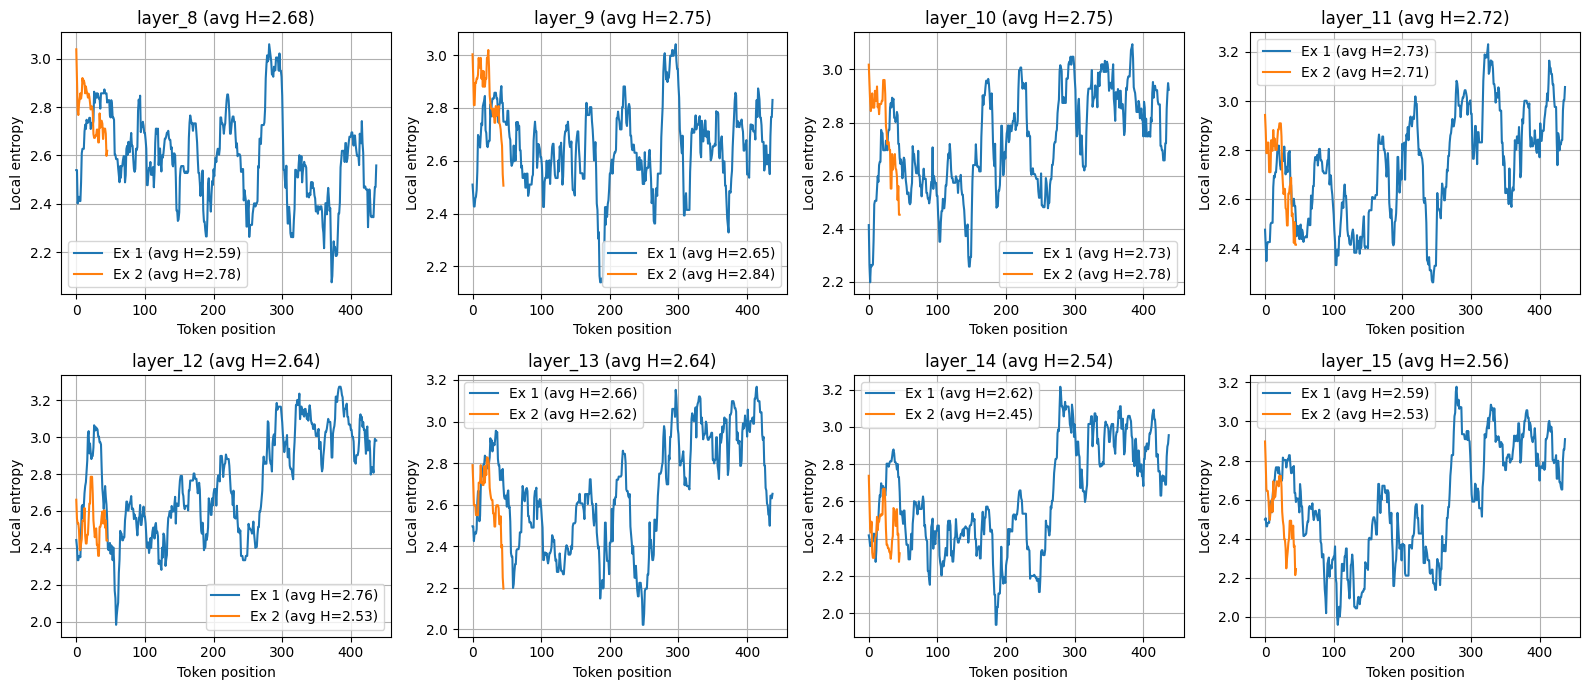

Layer 8: avg local entropy = 2.6836 bits
Layer 9: avg local entropy = 2.7475 bits
Layer 10: avg local entropy = 2.7532 bits
Layer 11: avg local entropy = 2.7215 bits
Layer 12: avg local entropy = 2.6416 bits
Layer 13: avg local entropy = 2.6423 bits
Layer 14: avg local entropy = 2.5387 bits
Layer 15: avg local entropy = 2.5590 bits

📊 Global average local entropy: 2.6609 bits


In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy
import random

# Paths to files
data_path = "/home/bukareszt/Downloads/trail_dataset_layers2.pt"
meta_path = "/home/bukareszt/Downloads/trail_dataset_layers2_metadata.pt"
num_examples = 3
layer_range = range(8, 16)

# Parameters for sliding entropy
window_size = 30
step = 1

# --- Load partial sequences ---
def load_partial_sequences(layer_name, data_path, meta_path, max_examples=5):
    data = torch.load(data_path, map_location="cpu")
    meta = torch.load(meta_path)

    embeddings = data[layer_name]
    gen_lens = meta["generated_lengths"]

    sequences = []
    idx = 0
    count = 0

    for length in gen_lens:
        if count >= max_examples:
            break
        seq = embeddings[idx:idx + length]
        sequences.append(seq)
        idx += length
        count += 1

    return sequences

# --- Cosine similarity between adjacent tokens ---
def compute_pairwise_similarities(sequence):
    return [
        F.cosine_similarity(sequence[i], sequence[i + 1], dim=0).item()
        for i in range(len(sequence) - 1)
    ]

# --- Visualization ---
n_layers = len(layer_range)
n_cols = 4
n_rows = (n_layers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), squeeze=False)
avg_entropies = []

for idx, layer_num in enumerate(layer_range):
    layer_name = f"layer_{layer_num}"
    row, col = divmod(idx, n_cols)

    sequences = load_partial_sequences(layer_name, data_path, meta_path, max_examples=num_examples)
    print(f"\n🔍 {layer_name}: {len(sequences)} sequences loaded")

    entropies = []
    ax = axes[row][col]

    for ex_idx, seq in enumerate(sequences):
        if len(seq) < window_size + 1:
            continue

        sims = compute_pairwise_similarities(seq)

        local_entropies = []
        for i in range(0, len(sims) - window_size + 1, step):
            window = sims[i:i + window_size]
            hist, _ = np.histogram(window, bins=30, range=(-1, 1), density=True)
            hist += 1e-10
            H = entropy(hist, base=2)
            local_entropies.append(H)

        if local_entropies:
            avg_local_H = np.mean(local_entropies)
            entropies.append(avg_local_H)
            ax.plot(local_entropies, label=f"Ex {ex_idx} (avg H={avg_local_H:.2f})")

    avg_H = np.mean(entropies) if entropies else 0.0
    avg_entropies.append(avg_H)
    ax.set_title(f"{layer_name} (avg H={avg_H:.2f})")
    ax.set_xlabel("Token position")
    ax.set_ylabel("Local entropy")
    ax.grid(True)
    ax.legend()

# Hide empty plots
for idx in range(len(layer_range), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()

# --- Summary ---
for i, layer_num in enumerate(layer_range):
    print(f"Layer {layer_num}: avg local entropy = {avg_entropies[i]:.4f} bits")

print(f"\n📊 Global average local entropy: {np.mean(avg_entropies):.4f} bits")



🔍 layer_8: 2 sequences loaded

🔍 layer_9: 2 sequences loaded

🔍 layer_10: 2 sequences loaded

🔍 layer_11: 2 sequences loaded

🔍 layer_12: 2 sequences loaded

🔍 layer_13: 2 sequences loaded

🔍 layer_14: 2 sequences loaded

🔍 layer_15: 2 sequences loaded


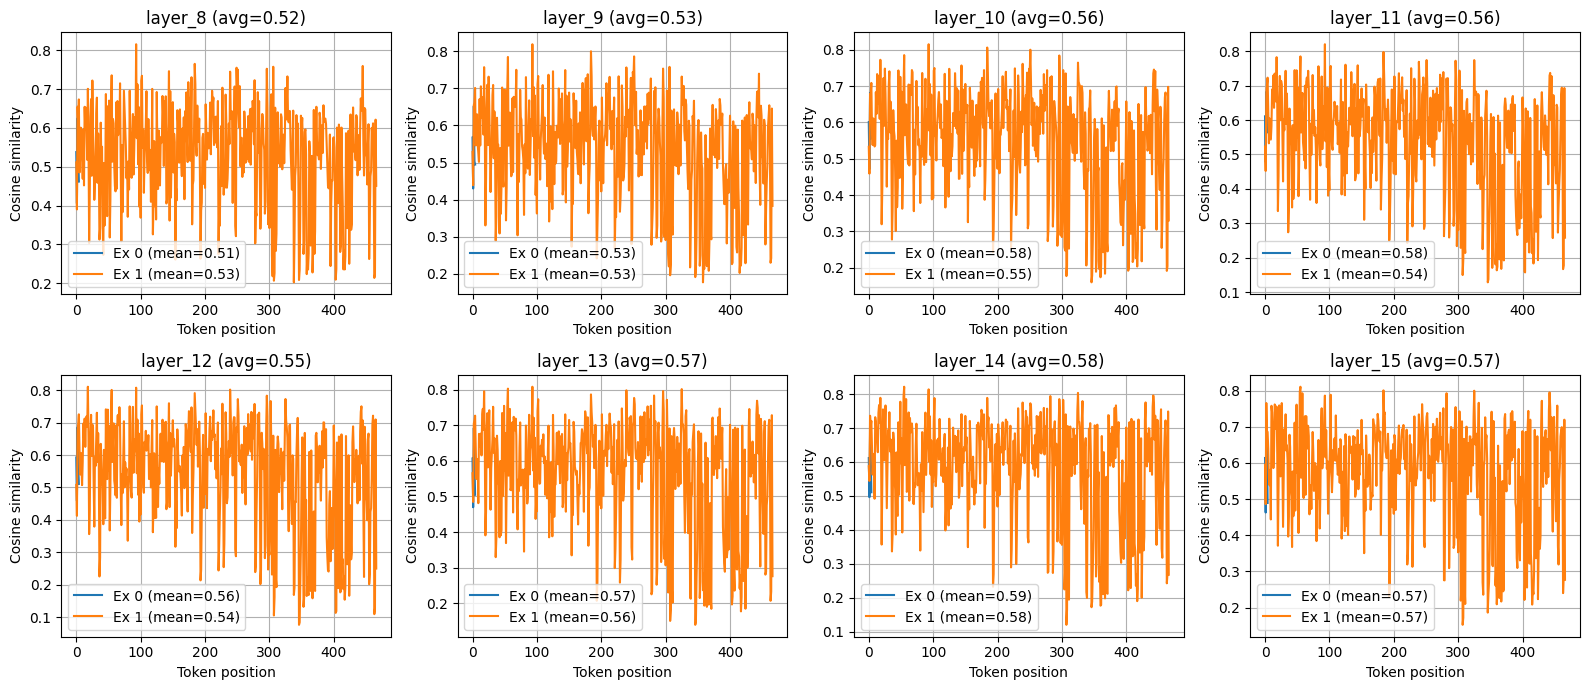


📊 Average cosine similarity per layer:
Layer 8: avg cosine similarity = 0.5216
Layer 9: avg cosine similarity = 0.5314
Layer 10: avg cosine similarity = 0.5609
Layer 11: avg cosine similarity = 0.5584
Layer 12: avg cosine similarity = 0.5499
Layer 13: avg cosine similarity = 0.5656
Layer 14: avg cosine similarity = 0.5824
Layer 15: avg cosine similarity = 0.5704

🔁 Global average similarity across all layers: 0.5551


In [11]:
def load_partial_sequences(layer_name, data_path, meta_path, max_examples=5):
    data = torch.load(data_path, map_location="cpu")
    meta = torch.load(meta_path)

    embeddings = data[layer_name]
    gen_lens = meta["generated_lengths"]

    sequences = []
    idx = 0
    count = 0

    for length in gen_lens:
        if count >= max_examples:
            break
        seq = embeddings[idx:idx + length]
        sequences.append(seq)
        idx += length
        count += 1

    return sequences

# --- Cosine similarity between adjacent tokens ---
def compute_pairwise_similarities(sequence):
    return [
        F.cosine_similarity(sequence[i], sequence[i + 1], dim=0).item()
        for i in range(len(sequence) - 1)
    ]

# --- Visualization ---
n_layers = len(layer_range)
n_cols = 4
n_rows = (n_layers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), squeeze=False)
avg_similarities = []

for idx, layer_num in enumerate(layer_range):
    layer_name = f"layer_{layer_num}"
    row, col = divmod(idx, n_cols)

    sequences = load_partial_sequences(layer_name, data_path, meta_path, max_examples=num_examples)
    print(f"\n🔍 {layer_name}: {len(sequences)} sequences loaded")

    mean_sims = []

    ax = axes[row][col]
    for i, seq in enumerate(sequences):
        if len(seq) < 2:
            continue
        sims = compute_pairwise_similarities(seq)
        mean_sim = np.mean(sims)
        mean_sims.append(mean_sim)
        ax.plot(sims, label=f"Ex {i} (mean={mean_sim:.2f})")

    layer_avg_sim = np.mean(mean_sims) if mean_sims else 0.0
    avg_similarities.append(layer_avg_sim)

    ax.set_title(f"{layer_name} (avg={layer_avg_sim:.2f})")
    ax.set_xlabel("Token position")
    ax.set_ylabel("Cosine similarity")
    ax.grid(True)
    ax.legend()

# Hide empty subplots
for idx in range(len(layer_range), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()

# --- Summary ---
print("\n📊 Average cosine similarity per layer:")
for i, layer_num in enumerate(layer_range):
    print(f"Layer {layer_num}: avg cosine similarity = {avg_similarities[i]:.4f}")

print(f"\n🔁 Global average similarity across all layers: {np.mean(avg_similarities):.4f}")